# How well do jobs and skills pay for Data Analysts, Data Scientists, and Data Engineers?

#### Methodology
1. Evaluate median salary for Data Analyst, Data Scientist, and Data Engineer roles in Australia.
2. Find median salary per skill for Data Analyst roles in Australia.
3. Visualize the highest-paying and most in-demand Data Analyst skills.


## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Salary Distribution by Job Title

Filter data for Australia and drop missing salary values.


In [2]:
# filter for the job titles and country
df_filtered = df[df['job_country'].isin(['Australia'])].dropna(subset=['salary_year_avg'])

Filter the dataframe to only contain Data Analyst, Data Scientist, and Data Engineer roles.

In [3]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

# filter the df for the top 3 job titles
df_top3 = df_filtered[df_filtered['job_title_short'].isin(job_titles)]

# order the job titles by median salary
job_order = df_top3.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_titles

['Data Analyst', 'Data Scientist', 'Data Engineer']

## Plot Salary Distributions

Plot salary distributions for the 3 target job titles using a box plot.


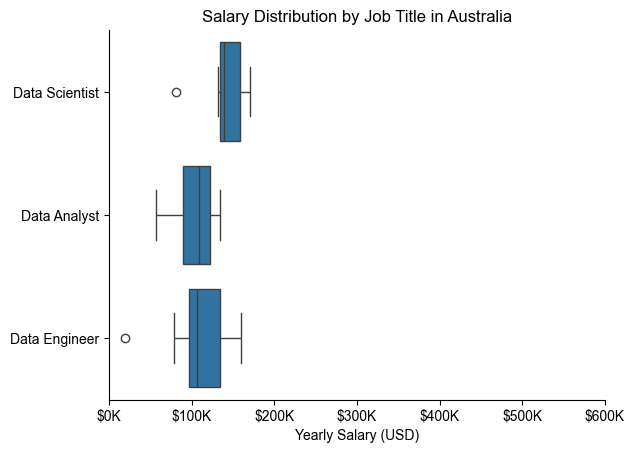

In [4]:
sns.boxplot(data=df_top3, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
sns.despine()

plt.title('Salary Distribution by Job Title in Australia')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()


## Salary Distribution Within Australia
Visualizing salary distributions for Data Analyst, Data Scientist, and Data Engineer roles in Australia.


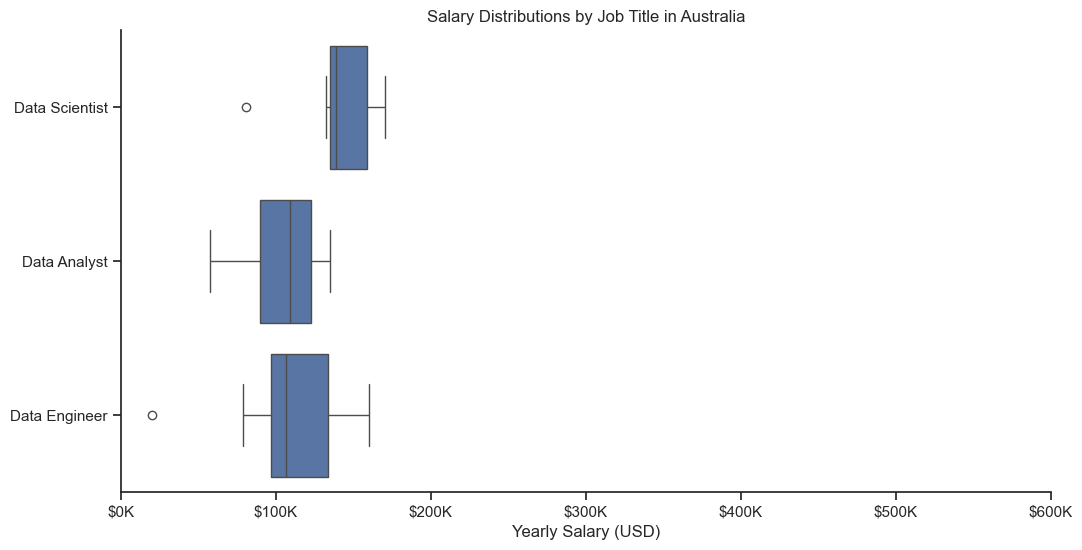

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top3, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
sns.despine()

plt.title('Salary Distributions by Job Title in Australia')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()


## Investigate Median Salary Vs Skill for Data Analysts

Filters the original dataset to get rows where the job title is `Data Analyst` and the country is Australia.


In [6]:
# Only get Data Analyst jobs in Australia
df_DA_filtered = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(['Australia']))].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_filtered = df_DA_filtered.dropna(subset=['salary_year_avg'])

df_DA_filtered = df_DA_filtered.explode('job_skills')

df_DA_filtered[['salary_year_avg', 'job_skills']].head(5)


,salary_year_avg,job_skills
42522,135000.0,sql
42522,135000.0,snowflake
42522,135000.0,tableau
407319,100500.0,sql
407319,100500.0,snowflake


## Determine The Highest Paid Skills and Most Demanded Skills

Gets the top-paying skills for Data Analysts in Australia by calculating the median salary for each skill. To avoid one-off postings dominating the ranking, keep only skills that appear in at least 3 salary-reporting job postings before selecting the top results.


In [7]:
df_DA_top_pay = df_DA_filtered.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay = df_DA_top_pay[df_DA_top_pay['count'] >= 3].sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay


,count,median
job_skills,,
sql,4,109500.0
excel,3,100500.0


Calculates the most in-demand skills for Data Analysts in Australia based on skill frequency, while removing one-off results by keeping only skills that appear in at least 2 salary-reporting postings. The filtered skills are then ordered by demand and secondarily by median salary for plotting.


In [8]:
df_DA_skills = df_DA_filtered.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_skills = df_DA_skills[df_DA_skills['count'] >= 2].sort_values(by=['count', 'median'], ascending=[False, False])

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills


,count,median
job_skills,,
snowflake,2,117750.0
sql,4,109500.0
excel,3,100500.0


Creates two horizontal bar charts: 
1. Displays the highest paid skills 
2. Shows the most in demand skills 

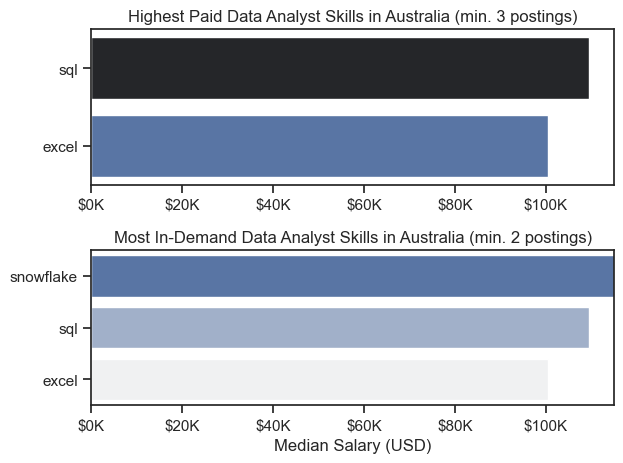

In [9]:
fig, ax = plt.subplots(2, 1)  

# Highest-paid skills with at least 3 salary-reporting postings
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Highest Paid Data Analyst Skills in Australia (min. 3 postings)')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Most in-demand skills with at least 2 salary-reporting postings
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Most In-Demand Data Analyst Skills in Australia (min. 2 postings)')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()
